In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, warnings, os
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses

# Track data loading
import psutil
import time

# Save & Load results
import pickle

In [2]:
import networkx as nx

import pandas as pd
import seaborn as sns

import datetime
from scipy import optimize

from itertools import product

# 1. Load data

In [3]:
st = time.time()

with open("data/graphs/G_filtered.gpickle", 'rb') as f:
    G_filtered = pickle.load(f)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 0.5416561603546143 mins
RAM memory % used: 18.3
RAM Used (GB): 71.183949824


In [4]:
def print_graph_info(G):
    print("Graph Type: ", type(G))
    print("Node Num: ", G.number_of_nodes())
    print("Edge Num: ", G.number_of_edges())
    print("Weight Sum: ", G.size(weight="weight"))

In [5]:
print_graph_info(G_filtered)

Graph Type:  <class 'networkx.classes.digraph.DiGraph'>
Node Num:  767553
Edge Num:  2165564
Weight Sum:  29991328.0


# 2. Variable preparations

## 2.1. Nodes Aligning (Static)

In [6]:
def get_keys_with_value(d, target_value):
    return list(filter(lambda k: d[k] == target_value, d))

In [7]:
nodes_aligning = nx.get_node_attributes(G_filtered, "extreme_aligning")

In [8]:
scientificNodes_aligned = get_keys_with_value(nodes_aligning, "scientific")
fakeNodes_aligned = get_keys_with_value(nodes_aligning, "fake")
uncertainNodes_aligned = get_keys_with_value(nodes_aligning, "uncertain")

In [9]:
alignedNodes = [scientificNodes_aligned, fakeNodes_aligned, uncertainNodes_aligned]
swayableNodes = get_keys_with_value(nodes_aligning, "NA")

## 2.2. TimeStamps

In [10]:
def cal_timestamps(date):
    
    start_timestamp = 1584482894
    
    # Define the start and end dates
    start_date = datetime.datetime.strptime('2020-03-17', '%Y-%m-%d')
    end_date = datetime.datetime.strptime(date, '%Y-%m-%d')

    # Calculate the difference in days
    difference_in_days = (end_date - start_date).days
    
    return start_timestamp + difference_in_days*24*60*60

In [11]:
def get_timeStamps_list(start_date_str, end_date_str):
    timeStamps_str_list = []
    
    # Convert the string dates to datetime.date objects
    start_date = datetime.datetime.strptime(start_date_str, "%Y-%m-%d").date()
    end_date = datetime.datetime.strptime(end_date_str, "%Y-%m-%d").date()

    # Current date starting from start_date
    current_date = start_date

    # Loop until the current date exceeds end_date
    counter = 0
    while current_date < end_date:
        
        if counter % 2 != 0:
            # Move to the 2th of the next month
            if current_date.month == 12:
                current_date = datetime.date(current_date.year + 1, 1, 2)
            else:
                current_date = datetime.date(current_date.year, current_date.month + 1, 2)
        else:
            # Move to the 17th of the same month
            current_date = datetime.date(current_date.year, current_date.month, 17)
            
        timeStamps_str_list.append(current_date.strftime("%Y-%m-%d"))
        
        counter += 1
            
    return timeStamps_str_list 

In [12]:
timeStamp1_list = get_timeStamps_list("2020-03-17", "2022-12-17")
timeStamp2_list = get_timeStamps_list("2020-04-17", "2023-01-17")
timeStamp3_list = get_timeStamps_list("2020-05-17", "2023-02-17")

## 2.3. Network construction (timeStamp1 - timeStamp2)

- Subgraph

In [13]:
def get_temporal_subgraph(G, timeStamp1, timeStamp2):
    
    subG = nx.DiGraph()
    
    node_timeStamps_dict = nx.get_node_attributes(G, "timeStamps")
    edge_timeStamps_dict = nx.get_edge_attributes(G, "timeStamps")
    
    for k,v in node_timeStamps_dict.items():
        index_mask = np.logical_and(v >= timeStamp1, v <= timeStamp2)
        if np.sum(index_mask) > 0:
            subG.add_node(k, timeStamps = G.nodes[k]['timeStamps'][index_mask], 
                             followers = G.nodes[k]['followers'][index_mask],
                             #friends = G.nodes[k]['friends'][index_mask],
                             #bot = G.nodes[k]['bot'][index_mask],
                             #verified = G.nodes[k]['verified'][index_mask],
                             extreme_aligning = G.nodes[k]['extreme_aligning'])
            
    for k,v in edge_timeStamps_dict.items():
        index_mask = np.logical_and(v >= timeStamp1, v <= timeStamp2)
        if np.sum(index_mask) > 0:
            subG.add_edge(k[0], k[1], weight = np.sum(index_mask),
                                      timeStamps = G.edges[k]['timeStamps'][index_mask], 
                                      newsCategories = G.edges[k]['newsCategories'][index_mask],
                                      newsCategoriesGeneralised = G.edges[k]['newsCategoriesGeneralised'][index_mask])
    
    # remove users whose follower count available, but doesn't retweet in the filtered network during specified period
    isolated_nodes = list(nx.isolates(subG))
    subG.remove_nodes_from(isolated_nodes)
    
    return subG

In [14]:
def get_subgraph_ofCategorisedRetweets(G, edge_stance, verbose = False):
    
    subG = nx.DiGraph()
    
    newsCategoriesGeneralised_dict = nx.get_edge_attributes(G, 'newsCategoriesGeneralised')
    
    for edge in list(G.edges):
        bool_arr = (newsCategoriesGeneralised_dict[edge] == edge_stance)
        if np.sum(bool_arr) > 0:
            subG.add_edge(edge[0], edge[1], weight = np.sum(bool_arr))
            
    if verbose:
        print_graph_info(subG)
    
    return subG

- Follower count

In [15]:
def get_subgraph_followerCount_begin(G, nodes):
    
    followerCount_begin_dict = {}

    for node in nodes:
        followerCount_begin_dict.update({node: G.nodes[node]["followers"][0]})
    
    return followerCount_begin_dict

In [16]:
def get_subgraph_followerCount_end(G, nodes):
    
    followerCount_end_dict = {}

    for node in nodes:
        followerCount_end_dict.update({node: G.nodes[node]["followers"][-1]})
    
    return followerCount_end_dict

## 2.4. Predicting follower count variations

In [17]:
def get_window_followerCountIncrease(nodes, timeStamp2, timeStamp3):
    
    followerCountSum_start = 0
    followerCountSum_end = 0
    
    for node in nodes:
        bool_arr1 = (np.array(G_filtered.nodes[node]['timeStamps']) >= timeStamp2)
        bool_arr2 = (np.array(G_filtered.nodes[node]['timeStamps']) <= timeStamp3)
        bool_arr = np.logical_and(bool_arr1, bool_arr2)
        if np.sum(bool_arr) > 1: 
            start = np.array(G_filtered.nodes[node]["followers"])[bool_arr][0]
            end = np.array(G_filtered.nodes[node]["followers"])[bool_arr][-1]
            
            followerCountSum_start += start
            followerCountSum_end += end
    
    return followerCountSum_end/followerCountSum_start - 1

In [18]:
def cal_true_increaseRate(timeStamp2_list, timeStamp3_list, stance):
    
    st = time.time()
    true_increaseRate_arr = np.zeros(len(timeStamp2_list))
    
    print('Counter:', end = ' ')
    for i in range(len(timeStamp2_list)):
        print(i, end = ' ')
        timeStamp2_convert = cal_timestamps(timeStamp2_list[i]); timeStamp3_convert = cal_timestamps(timeStamp3_list[i])
        true_increaseRate_arr[i] = get_window_followerCountIncrease(alignedNodes[stance], timeStamp2_convert, timeStamp3_convert)
    
    save_address = "results/FJ/rate_1month/trueIncreaseRateArr" + "_stance_" + str(stance) + ".pkl"
    with open(save_address, "wb") as file:
        pickle.dump(true_increaseRate_arr, file)
    
    et = time.time(); elapsed_time = et - st
    print('Complete. Execution time:', elapsed_time/60, 'mins')

In [158]:
cal_true_increaseRate(timeStamp2_list, timeStamp3_list, stance = 0)

Counter: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 Complete. Execution time: 2.118901824951172 mins


In [159]:
cal_true_increaseRate(timeStamp2_list, timeStamp3_list, stance = 1)

Counter: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 Complete. Execution time: 0.33905956347783406 mins


In [160]:
cal_true_increaseRate(timeStamp2_list, timeStamp3_list, stance = 2)

Counter: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 Complete. Execution time: 5.3435963034629825 mins


# 3. Simulation

In [19]:
def intersection(lst1, lst2):
    return list(set(lst1).intersection(lst2))

In [20]:
def get_keys_with_value(d, target_value):
    return list(filter(lambda k: d[k] == target_value, d))

In [21]:
def get_keys_without_value(d, target_value):
    return list(filter(lambda k: d[k] != target_value, d))

In [22]:
def get_value_with_keys(d, target_keys):
    return list(map(d.get, target_keys))

In [23]:
def compute_A2W(A):
    
    A_tran = A.T
    row_sums = A_tran.sum(axis=1, keepdims=True)
    # Avoid division by zero
    row_sums[row_sums == 0] = 1
    
    W = A_tran / row_sums
    
    return W

In [24]:
def compute_FJ_conv(W, λ, u):

    Λ = np.diag(λ)
    I = np.identity(len(λ))
    V = np.dot(np.linalg.inv(I - np.dot(Λ, W)), I - Λ)
    
    return V @ u

In [25]:
def assign_λ_acrossRuns(num_runs = 100, seed = 2025):
    
    rng = np.random.default_rng(seed = seed)
    
    alignedNodes_flatten = sum(alignedNodes, [])
    λ_alignedNodes = np.zeros((len(alignedNodes_flatten), num_runs)) # stubborn
    λ_swayableNodes = rng.uniform(0, 1, (len(swayableNodes), num_runs))
    λ_allNodes = np.vstack((λ_alignedNodes, λ_swayableNodes))
    
    λ_acrossRuns = {k: v for k, v in zip(alignedNodes_flatten + swayableNodes, λ_allNodes)}
    
    return λ_acrossRuns

In [26]:
from collections import deque
def _reachable_multi_source(G, sources):
    """Return set of nodes reachable from any source (inclusive) in a DiGraph."""
    seen = set(sources)
    q = deque(sources)
    succ = G.succ if G.is_directed() else G.adj
    while q:
        u = q.popleft()
        for v in succ[u]:
            if v not in seen:
                seen.add(v)
                q.append(v)
    return seen

In [27]:
def get_window_creators_and_listeners(window_stance_subG, window_aligned_nodes, window_swayable_nodes):
    # Use sets
    aligned = set(window_aligned_nodes)
    swayable = set(window_swayable_nodes)

    # Induced subgraph view (cheap in NetworkX)
    H = window_stance_subG.subgraph(aligned | swayable)

    # 1) Creators: aligned nodes that can reach at least one swayable
    #    Do one reverse traversal from all swayable to find their ancestors.
    Hr = H.reverse(copy=False)
    ancestors_of_swayable = _reachable_multi_source(Hr, swayable)
    creators_aligned_nodes = list(ancestors_of_swayable & aligned)

    # 2) Listeners: swayable nodes reachable from any creator
    reachable_from_creators = _reachable_multi_source(H, creators_aligned_nodes)
    listeners_swayable_nodes = list(reachable_from_creators & swayable)

    # 3) Final induced subgraph on creators ∪ listeners
    H_cl = H.subgraph(set(creators_aligned_nodes) | set(listeners_swayable_nodes))

    return creators_aligned_nodes, listeners_swayable_nodes, H_cl

In [28]:
def follower_sim(timeStamp1, timeStamp2, stance):
    
    st = time.time()
    
    # construct networks
    timeStamp1_convert = cal_timestamps(timeStamp1); timeStamp2_convert = cal_timestamps(timeStamp2)
    
    window_subG = get_temporal_subgraph(G_filtered, timeStamp1_convert, timeStamp2_convert)
    window_stance_subG = get_subgraph_ofCategorisedRetweets(window_subG, edge_stance = stance, verbose = False)
    
    window_aligned_nodes = intersection(list(window_stance_subG.nodes), alignedNodes[stance])
    window_swayable_nodes = intersection(list(window_stance_subG.nodes), swayableNodes)
    
    temp = time.time(); elapsed_time = temp - st
    print('Network extraction complete. Execution time:', elapsed_time/60, 'mins')
    
    # subgraph: creators and listeners
    creators_aligned_nodes, listeners_swayable_nodes, window_stance_subG_cl = get_window_creators_and_listeners(window_stance_subG, window_aligned_nodes, window_swayable_nodes)
    temp2 = time.time(); elapsed_time = temp2 - temp
    print('Creators and listeners subgraph extraction complete. Execution time:', elapsed_time/60, 'mins')
    
    # followers count (timeStamp2)
    nodelist = creators_aligned_nodes + listeners_swayable_nodes
    creators_aligned_followerCountSum = np.sum(list(get_subgraph_followerCount_end(window_subG, creators_aligned_nodes).values()))
    followerCount = np.array(list(get_subgraph_followerCount_end(window_subG, nodelist).values()))
    
    # FJ convergence
    u = np.array([1] * len(creators_aligned_nodes) + [0] * len(listeners_swayable_nodes))
    A = nx.adjacency_matrix(window_stance_subG_cl, nodelist = nodelist).toarray()
    W = compute_A2W(A)
    
    results = np.zeros(len(λ_acrossRuns[2]))
    for i in range(len(λ_acrossRuns[2])): # num_runs = len(λ_acrossRuns[2])
        λ = np.array(get_value_with_keys(λ_acrossRuns, nodelist))[:, i]
        x_conv = compute_FJ_conv(W, λ, u)
        follower_gained = np.sum(x_conv * (1 - u) * followerCount) # follower gained from swayable nodes
        rate = follower_gained / creators_aligned_followerCountSum
        results[i] = rate
    
    temp3 = time.time(); elapsed_time = temp3 - temp2
    print('Prop computation complete. Execution time:', elapsed_time/60, 'mins')
    
    save_address = "Results/FJ/rate_1month/timeStamp1_" + timeStamp1 + "_timeStamp2_" + timeStamp2 + "_stance_" + str(stance) + ".pkl" 
    with open(save_address, "wb") as file:
        pickle.dump(results, file)
    et = time.time(); elapsed_time = et - st
    print('Results saved. Total Execution time:', elapsed_time/60, 'mins')

In [29]:
λ_acrossRuns = assign_λ_acrossRuns(num_runs = 20, seed = 2025)

In [197]:
for i in range(len(timeStamp1_list)):
    timeStamp1 = timeStamp1_list[i]; timeStamp2 = timeStamp2_list[i]
    for stance in range(3):
        print("timeStamp1: " + timeStamp1 + " timeStamp2: " + timeStamp2 + " stance: "  + str(stance))
        follower_sim(timeStamp1, timeStamp2, stance)
        print("========================================")
        print()

timeStamp1: 2020-03-17 timeStamp2: 2020-04-17 stance: 0
Network extraction complete. Execution time: 0.7873941580454509 mins
Creators and listeners subgraph extraction complete. Execution time: 0.011307867368062337 mins
Prop computation complete. Execution time: 4.478037945429484 mins
Results saved. Total Execution time: 5.276781725883484 mins

timeStamp1: 2020-03-17 timeStamp2: 2020-04-17 stance: 1
Network extraction complete. Execution time: 0.6606902798016866 mins
Creators and listeners subgraph extraction complete. Execution time: 0.002140005429585775 mins
Prop computation complete. Execution time: 0.0025032718976338705 mins
Results saved. Total Execution time: 0.6653582016626994 mins

timeStamp1: 2020-03-17 timeStamp2: 2020-04-17 stance: 2
Network extraction complete. Execution time: 0.7806816856066386 mins
Creators and listeners subgraph extraction complete. Execution time: 0.013322047392527262 mins
Prop computation complete. Execution time: 6.616928497950236 mins
Results saved. 

Network extraction complete. Execution time: 0.7961601853370667 mins
Creators and listeners subgraph extraction complete. Execution time: 0.012816635767618816 mins
Prop computation complete. Execution time: 5.748776789506277 mins
Results saved. Total Execution time: 6.5578021049499515 mins

timeStamp1: 2020-07-02 timeStamp2: 2020-08-02 stance: 1
Network extraction complete. Execution time: 0.6993281801541646 mins
Creators and listeners subgraph extraction complete. Execution time: 0.002631254990895589 mins
Prop computation complete. Execution time: 0.0017081618309020997 mins
Results saved. Total Execution time: 0.7036864797274271 mins

timeStamp1: 2020-07-02 timeStamp2: 2020-08-02 stance: 2
Network extraction complete. Execution time: 0.8616403341293335 mins
Creators and listeners subgraph extraction complete. Execution time: 0.014971717198689779 mins
Prop computation complete. Execution time: 7.157992577552795 mins
Results saved. Total Execution time: 8.034648879369099 mins

timeStamp

Creators and listeners subgraph extraction complete. Execution time: 0.01087188720703125 mins
Prop computation complete. Execution time: 4.221804122130076 mins
Results saved. Total Execution time: 4.9794464667638145 mins

timeStamp1: 2020-10-17 timeStamp2: 2020-11-17 stance: 1
Network extraction complete. Execution time: 0.7668098568916321 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0018646597862243652 mins
Prop computation complete. Execution time: 0.0008299748102823893 mins
Results saved. Total Execution time: 0.7695244749387106 mins

timeStamp1: 2020-10-17 timeStamp2: 2020-11-17 stance: 2
Network extraction complete. Execution time: 0.9723327279090881 mins
Creators and listeners subgraph extraction complete. Execution time: 0.01385946273803711 mins
Prop computation complete. Execution time: 4.189544753233592 mins
Results saved. Total Execution time: 5.175808850924174 mins

timeStamp1: 2020-11-02 timeStamp2: 2020-12-02 stance: 0
Network extraction comp

Prop computation complete. Execution time: 0.7580853501955668 mins
Results saved. Total Execution time: 1.5445683598518372 mins

timeStamp1: 2021-02-02 timeStamp2: 2021-03-02 stance: 1
Network extraction complete. Execution time: 0.6733542839686076 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0015445709228515624 mins
Prop computation complete. Execution time: 0.0009834806124369303 mins
Results saved. Total Execution time: 0.6759007453918457 mins

timeStamp1: 2021-02-02 timeStamp2: 2021-03-02 stance: 2
Network extraction complete. Execution time: 0.6703279415766398 mins
Creators and listeners subgraph extraction complete. Execution time: 0.008908637364705404 mins
Prop computation complete. Execution time: 1.6524157842000327 mins
Results saved. Total Execution time: 2.331691078344981 mins

timeStamp1: 2021-02-17 timeStamp2: 2021-03-17 stance: 0
Network extraction complete. Execution time: 0.618151330947876 mins
Creators and listeners subgraph extraction com

Prop computation complete. Execution time: 1.686700705687205 mins
Results saved. Total Execution time: 2.3554800510406495 mins

timeStamp1: 2021-05-17 timeStamp2: 2021-06-17 stance: 1
Network extraction complete. Execution time: 0.6442481239636739 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0023241599400838217 mins
Prop computation complete. Execution time: 0.0024466554323832193 mins
Results saved. Total Execution time: 0.6490389188130696 mins

timeStamp1: 2021-05-17 timeStamp2: 2021-06-17 stance: 2
Network extraction complete. Execution time: 0.6178502162297567 mins
Creators and listeners subgraph extraction complete. Execution time: 0.00795576572418213 mins
Prop computation complete. Execution time: 0.9456227978070577 mins
Results saved. Total Execution time: 1.5714651226997376 mins

timeStamp1: 2021-06-02 timeStamp2: 2021-07-02 stance: 0
Network extraction complete. Execution time: 0.6575309872627259 mins
Creators and listeners subgraph extraction com

Prop computation complete. Execution time: 0.32023431062698365 mins
Results saved. Total Execution time: 0.9433159907658895 mins

timeStamp1: 2021-09-02 timeStamp2: 2021-10-02 stance: 1
Network extraction complete. Execution time: 0.6764431556065877 mins
Creators and listeners subgraph extraction complete. Execution time: 0.002659765879313151 mins
Prop computation complete. Execution time: 0.0036235451698303223 mins
Results saved. Total Execution time: 0.6827584902445475 mins

timeStamp1: 2021-09-02 timeStamp2: 2021-10-02 stance: 2
Network extraction complete. Execution time: 0.6734378178914388 mins
Creators and listeners subgraph extraction complete. Execution time: 0.008823255697886149 mins
Prop computation complete. Execution time: 0.821663248538971 mins
Results saved. Total Execution time: 1.5039618134498596 mins

timeStamp1: 2021-09-17 timeStamp2: 2021-10-17 stance: 0
Network extraction complete. Execution time: 0.6482265432675679 mins
Creators and listeners subgraph extraction co

Prop computation complete. Execution time: 0.3987109939257304 mins
Results saved. Total Execution time: 1.0732215960820517 mins

timeStamp1: 2021-12-17 timeStamp2: 2022-01-17 stance: 1
Network extraction complete. Execution time: 0.6432360847791035 mins
Creators and listeners subgraph extraction complete. Execution time: 0.002098337809244792 mins
Prop computation complete. Execution time: 0.0017942190170288086 mins
Results saved. Total Execution time: 0.6471471786499023 mins

timeStamp1: 2021-12-17 timeStamp2: 2022-01-17 stance: 2
Network extraction complete. Execution time: 0.6585318485895792 mins
Creators and listeners subgraph extraction complete. Execution time: 0.008244625727335612 mins
Prop computation complete. Execution time: 0.6944088816642762 mins
Results saved. Total Execution time: 1.3612255056699116 mins

timeStamp1: 2022-01-02 timeStamp2: 2022-02-02 stance: 0
Network extraction complete. Execution time: 0.592951754728953 mins
Creators and listeners subgraph extraction com

Prop computation complete. Execution time: 0.03350552320480347 mins
Results saved. Total Execution time: 0.5281638065973918 mins

timeStamp1: 2022-04-02 timeStamp2: 2022-05-02 stance: 1
Network extraction complete. Execution time: 0.49158283074696857 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0006825129191080729 mins
Prop computation complete. Execution time: 0.00015735228856404623 mins
Results saved. Total Execution time: 0.4924410661061605 mins

timeStamp1: 2022-04-02 timeStamp2: 2022-05-02 stance: 2
Network extraction complete. Execution time: 0.5451292037963867 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0028685688972473144 mins
Prop computation complete. Execution time: 0.062118955453236896 mins
Results saved. Total Execution time: 0.6101511796315511 mins

timeStamp1: 2022-04-17 timeStamp2: 2022-05-17 stance: 0
Network extraction complete. Execution time: 0.4916051745414734 mins
Creators and listeners subgraph extrac

Prop computation complete. Execution time: 0.019356520970662434 mins
Results saved. Total Execution time: 0.49784015417099 mins

timeStamp1: 2022-07-17 timeStamp2: 2022-08-17 stance: 1
Network extraction complete. Execution time: 0.47378840843836467 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0005438764890034994 mins
Prop computation complete. Execution time: 0.0001517772674560547 mins
Results saved. Total Execution time: 0.47450358072916665 mins

timeStamp1: 2022-07-17 timeStamp2: 2022-08-17 stance: 2
Network extraction complete. Execution time: 0.4785050431887309 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0023819645245869952 mins
Prop computation complete. Execution time: 0.04272080659866333 mins
Results saved. Total Execution time: 0.5236454804738363 mins

timeStamp1: 2022-08-02 timeStamp2: 2022-09-02 stance: 0
Network extraction complete. Execution time: 0.5198592424392701 mins
Creators and listeners subgraph extracti

Prop computation complete. Execution time: 0.011107246081034342 mins
Results saved. Total Execution time: 0.47770822445551553 mins

timeStamp1: 2022-11-02 timeStamp2: 2022-12-02 stance: 1
Network extraction complete. Execution time: 0.5087471167246501 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0004527807235717773 mins
Prop computation complete. Execution time: 9.216864903767903e-05 mins
Results saved. Total Execution time: 0.5093100706736247 mins

timeStamp1: 2022-11-02 timeStamp2: 2022-12-02 stance: 2
Network extraction complete. Execution time: 0.46576685110727944 mins
Creators and listeners subgraph extraction complete. Execution time: 0.0018849690755208333 mins
Prop computation complete. Execution time: 0.028113412857055663 mins
Results saved. Total Execution time: 0.4957998514175415 mins

timeStamp1: 2022-11-17 timeStamp2: 2022-12-17 stance: 0
Network extraction complete. Execution time: 0.47113852898279823 mins
Creators and listeners subgraph extr

# 4. Optimisation

- Load results

In [30]:
def load_results(timeStamp1_list, timeStamp2_list, timeStamp3_list, num_runs):
    
    st = time.time()
    
    # simulation results
    keys_list = [i for i in range(num_runs)]
    prop_arr = []
    
    for i in range(len(timeStamp1_list)):
        timeStamp1 = timeStamp1_list[i]; timeStamp2 = timeStamp2_list[i]
        temp = []
        for stance in range(3):
            save_address = "results/FJ/rate_1month/timeStamp1_" + timeStamp1 + "_timeStamp2_" + timeStamp2 + "_stance_" + str(stance) + ".pkl" 
            with open(save_address, "rb") as file:               
                load_arr = pickle.load(file)
            temp.append(np.array(load_arr))
        prop_arr.append(temp)
    prop_dict = dict(zip(keys_list, np.array(prop_arr).T)) 
    
    # true increase rate
    true_increaseRate_arr = []
    for i in range(3):
        save_address = "results/FJ/rate_1month/trueIncreaseRateArr" + "_stance_" + str(i) + ".pkl"
        with open(save_address, "rb") as file:
            true_increaseRate_arr.append(pickle.load(file))
    true_increaseRate_arr = np.array(true_increaseRate_arr)
    
    et = time.time(); elapsed_time = et - st
    print('Load results complete. Execution time:', elapsed_time/60, 'mins')
    
    return prop_dict, true_increaseRate_arr

In [31]:
num_runs = len(λ_acrossRuns[2])
prop_dict, true_increaseRate_arr = load_results(timeStamp1_list, timeStamp2_list, timeStamp3_list, num_runs)

Load results complete. Execution time: 0.05647135575612386 mins


In [32]:
def get_temporal_RetweetCountSum(nodes, timeStamp1_list, timeStamp2_list):
    
    timeStamp1_list_convert = [cal_timestamps(timeStamp1) for timeStamp1 in timeStamp1_list]
    timeStamp2_list_convert = [cal_timestamps(timeStamp2) for timeStamp2 in timeStamp2_list]
    
    interval_list = list(zip(timeStamp1_list_convert, timeStamp2_list_convert))
    temporal_retweet_count = np.zeros(len(interval_list))
    
    in_edges = list(G_filtered.in_edges(nodes))
    out_edges = list(G_filtered.out_edges(nodes))
    
    timestamps = []
    for edge in list(set(in_edges + out_edges)):
        timestamps += list(np.array(G_filtered.edges[edge]["timeStamps"]))
    timestamps = np.array(timestamps)
    
    for i in range(len(interval_list)):
        bool_arr = np.logical_and(timestamps >= interval_list[i][0], timestamps <= interval_list[i][1])
        temporal_retweet_count[i] += np.sum(bool_arr) 
    
    return temporal_retweet_count

In [33]:
st = time.time()

scientificNodes_retweetCountSum = get_temporal_RetweetCountSum(scientificNodes_aligned, timeStamp2_list, timeStamp3_list)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 0.09108529885609945 mins
RAM memory % used: 18.4
RAM Used (GB): 71.355723776


In [34]:
st = time.time()

fakeNodes_retweetCountSum = get_temporal_RetweetCountSum(fakeNodes_aligned, timeStamp2_list, timeStamp3_list)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 0.011809158325195312 mins
RAM memory % used: 18.4
RAM Used (GB): 71.319953408


In [35]:
st = time.time()

uncertainNodes_retweetCountSum = get_temporal_RetweetCountSum(uncertainNodes_aligned, timeStamp2_list, timeStamp3_list)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 0.23198901017506918 mins
RAM memory % used: 18.4
RAM Used (GB): 71.27154688


In [36]:
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

def cal_scaling_para(true_arr, pred_arr):
    true_arr = np.asarray(true_arr, dtype=float)
    pred_arr = np.asarray(pred_arr, dtype=float)

    def mse_loss(delta):
        pred_scaled = delta * pred_arr
        diff = true_arr - pred_scaled
        return np.mean(diff ** 2)

    # unbounded minimization
    result = minimize_scalar(mse_loss)

    return result

In [37]:
avg_arr1 = np.array([prop_dict[seed][0, :] for seed in range(20)]).mean(axis=0)
avg_arr2 = np.array([prop_dict[seed][1, :] for seed in range(20)]).mean(axis=0)
avg_arr3 = np.array([prop_dict[seed][2, :] for seed in range(20)]).mean(axis=0)

In [38]:
result = cal_scaling_para(list(true_increaseRate_arr[0, :]) + list(true_increaseRate_arr[1, :]) + list(true_increaseRate_arr[2, :]), list(avg_arr1) + list(avg_arr2) + list(avg_arr3))
result

     fun: 3.8582409937688325e-05
 message: '\nOptimization terminated successfully;\nThe returned value satisfies the termination criteria\n(using xtol = 1.48e-08 )'
    nfev: 9
     nit: 5
 success: True
       x: 0.0001130217127661301

In [39]:
delta = result["x"] 

In [40]:
avg_pred_arr1 = np.array([prop_dict[seed][0, :] * delta for seed in range(20)]).mean(axis=0) 
avg_pred_arr2 = np.array([prop_dict[seed][1, :] * delta for seed in range(20)]).mean(axis=0) 
avg_pred_arr3 = np.array([prop_dict[seed][2, :] * delta for seed in range(20)]).mean(axis=0)

std_pred_arr1 = np.array([prop_dict[seed][0, :] * delta for seed in range(20)]).std(axis=0)
std_pred_arr2 = np.array([prop_dict[seed][1, :] * delta for seed in range(20)]).std(axis=0)
std_pred_arr3 = np.array([prop_dict[seed][2, :] * delta for seed in range(20)]).std(axis=0)

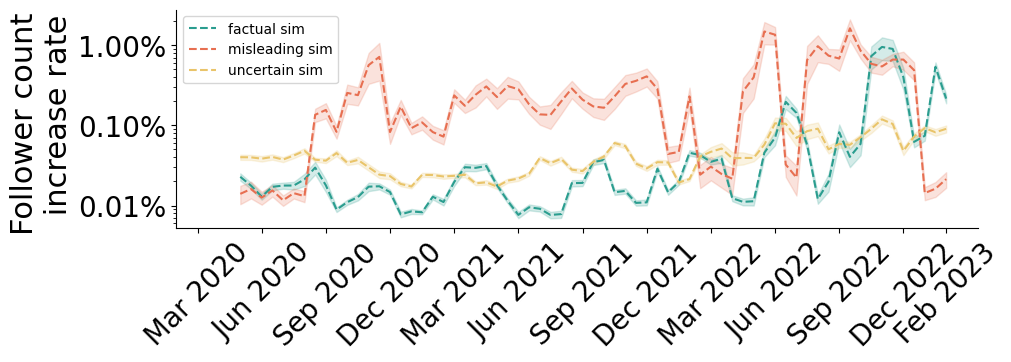

In [43]:
from matplotlib.ticker import PercentFormatter

colour_palette = {"scientific":"#2a9d8f", "fake":"#e76f51", "uncertain":"#e9c46a"}

fig, axs = plt.subplots(figsize = (10, 3.5), constrained_layout = True)
idx = np.arange(len(prop_dict[2][0, :]))
plt.plot(idx, avg_pred_arr1, linestyle = "dashed", color = colour_palette["scientific"], label = "factual sim")
plt.plot(idx, avg_pred_arr2, linestyle = "dashed", color = colour_palette["fake"], label = "misleading sim")
plt.plot(idx, avg_pred_arr3, linestyle = "dashed", color = colour_palette["uncertain"], label = "uncertain sim")

plt.fill_between(idx, avg_pred_arr1 - 1 * std_pred_arr1, avg_pred_arr1 + 1 * std_pred_arr1, alpha = 0.2, color = colour_palette["scientific"])
plt.fill_between(idx, avg_pred_arr2 - 1 * std_pred_arr2, avg_pred_arr2 + 1 * std_pred_arr2, alpha = 0.2, color = colour_palette["fake"])
plt.fill_between(idx, avg_pred_arr3 - 1 * std_pred_arr3, avg_pred_arr3 + 1 * std_pred_arr3, alpha = 0.2, color = colour_palette["uncertain"])

index = list(np.array([(i)*6 for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]]) - 4) + [66]
x_tick = ["Mar 2020", "Jun 2020", "Sep 2020", "Dec 2020", "Mar 2021", "Jun 2021", "Sep 2021", "Dec 2021", "Mar 2022", "Jun 2022", "Sep 2022", "Dec 2022", "Feb 2023"]
plt.xticks(index, x_tick, fontsize = 20, rotation = 45) 
plt.yticks(fontsize = 20)
plt.ylabel('Follower count \n increase rate', fontsize = 22)

plt.xlim(min(idx)-6, max(idx)+3)
#plt.ylim(0,5)
plt.yscale('log')
plt.legend(fontsize = 10)
axs.spines['right'].set_visible(False); axs.spines['top'].set_visible(False)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

fig.savefig('figures/SM_fig11a.png', dpi=400, bbox_inches = 'tight')

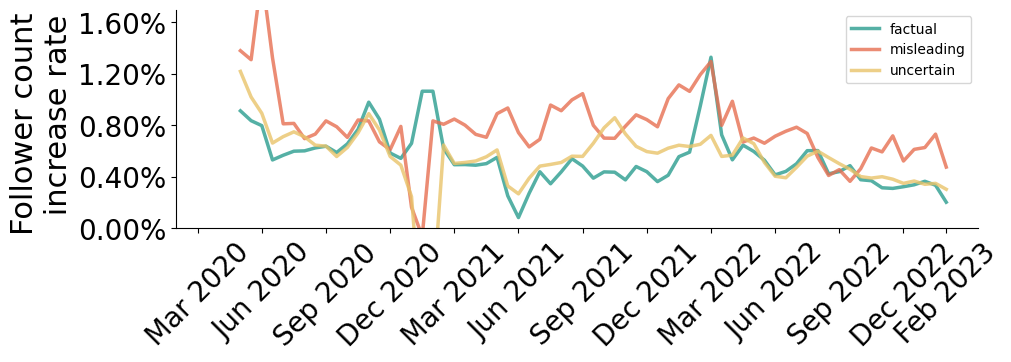

In [45]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(figsize = (10, 3.5), constrained_layout = True)
idx = np.arange(0, len(prop_dict[2][0, :]), 1)
#plt.plot(idx, avg_arr1/10**8 * 3, linestyle = "dashed", color = colour_palette["scientific"], label = "factual sim", linewidth = 2.5, alpha = 1)
#plt.plot(idx, avg_arr2/10**8 * 1.2, linestyle = "dashed", color = colour_palette["fake"], label = "misleading sim", linewidth = 2.5, alpha = 1)
#plt.plot(idx, avg_arr3/10**8 * 0.8, linestyle = "dashed", color = colour_palette["uncertain"], label = "uncertain sim", linewidth = 2.5, alpha = 1)

plt.plot(idx, true_increaseRate_arr[0, :], color = colour_palette["scientific"], linewidth = 2.5, alpha = 0.8, label = "factual")
plt.plot(idx, true_increaseRate_arr[1, :], color = colour_palette["fake"], linewidth = 2.5, alpha = 0.8, label = "misleading")
plt.plot(idx, true_increaseRate_arr[2, :], color = colour_palette["uncertain"], linewidth = 2.5, alpha = 0.8, label = "uncertain")

index = list(np.array([(i)*6 for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]]) - 4) + [66]
x_tick = ["Mar 2020", "Jun 2020", "Sep 2020", "Dec 2020", "Mar 2021", "Jun 2021", "Sep 2021", "Dec 2021", "Mar 2022", "Jun 2022", "Sep 2022", "Dec 2022", "Feb 2023"]
plt.xticks(index, x_tick, fontsize = 20, rotation = 45) 
plt.yticks(fontsize = 20)
plt.ylabel('Follower count \n increase rate', fontsize = 22)

plt.xlim(min(idx)-6, max(idx)+3)
plt.ylim(0.000, 0.017)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
axs.yaxis.set_major_locator(MaxNLocator(nbins=5))
axs.spines['right'].set_visible(False); axs.spines['top'].set_visible(False)
plt.legend(fontsize = 10)
fig.savefig('figures/SM_fig11c.png', dpi=400, bbox_inches = 'tight')